# Architecture 3

In [1]:
import numpy as np
import pandas as pd
import torch
from types import SimpleNamespace


In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
SRC_ROOT = PROJECT_ROOT / "src"

if str(SRC_ROOT) not in sys.path:
    sys.path.append(str(SRC_ROOT))


import matplotlib.pyplot as plt
from deep_belief_betting.parameters import Parameters
from deep_belief_betting.market_sim import MarketSim
from deep_belief_betting.pretraining_path_generator import PretrainingPathGenerator
from deep_belief_betting.prediction_market_env import PredictionMarketEnv
from deep_belief_betting.smoke_train import SmokeTrainConfig, run_smoke_training

# Colab setup - if applicable 

# 1. Pulling Sim Data

In [3]:
def getSimData(seed):

    params = Parameters.from_yaml(PROJECT_ROOT / "configs" / "default.yaml")

    sim = MarketSim(params)
    state = sim.reset(seed=seed)

    rows = []
    rows.append(
        {
            "step": state.step,
            "time_to_resolution": state.time_to_resolution,
            "x": state.x,
            "q": state.q,
            "public_probability": state.public_probability,
            "latent_probability": state.latent_probability,
            "delta_q": state.delta_q,
            "informed_flow": state.informed_flow,
            "noise_flow": state.noise_flow,
            "terminal_outcome": state.terminal_outcome,
        }
    )

    done = False
    while not done:
        state, done = sim.step()
        rows.append(
            {
                "step": state.step,
                "time_to_resolution": state.time_to_resolution,
                "x": state.x,
                "q": state.q,
                "public_probability": state.public_probability,
                "latent_probability": state.latent_probability,
                "delta_q": state.delta_q,
                "informed_flow": state.informed_flow,
                "noise_flow": state.noise_flow,
                "terminal_outcome": state.terminal_outcome,
            }
        )

    return pd.DataFrame(rows)
    

In [4]:
def sim2model(n_examples, T_steps):
    
    sim_cols= []

    for i in range(T_steps+1):
        sim_cols.append("prob_"+str(i))
        sim_cols.append("feat_"+str(i))
        sim_cols.append("latent_"+str(i))

    df_sim = pd.DataFrame(columns= sim_cols)

    for n in range(n_examples):
        df_one_path= getSimData(seed=n)
        
        for i in range(T_steps+1):
            df_sim.loc[n,"prob_"+str(i)]= df_one_path.loc[i,"public_probability"]
            df_sim.loc[n,"feat_"+str(i)]= df_one_path.loc[i, "informed_flow"] + df_one_path.loc[i, "noise_flow"]
            df_sim.loc[n, "latent_"+str(i)]= df_one_path.loc[i,"latent_probability"]
            
            
    return df_sim

In [5]:
df= sim2model(100,60)
df.head()

,prob_0,feat_0,latent_0,prob_1,feat_1,latent_1,prob_2,feat_2,latent_2,prob_3,...,latent_57,prob_58,feat_58,latent_58,prob_59,feat_59,latent_59,prob_60,feat_60,latent_60
0,0.5,0.0,0.5,0.512497,1.0,0.546837,0.562177,4.0,0.574588,0.562177,...,0.825164,0.817574,-4.0,0.791101,0.817574,0.0,0.805253,0.817574,0.0,0.889092
1,0.5,0.0,0.5,0.46257,-3.0,0.544286,0.46257,0.0,0.5015,0.413382,...,0.942257,0.934011,3.0,0.959199,0.934011,0.0,0.962768,0.934011,0.0,0.961804
2,0.5,0.0,0.5,0.5,0.0,0.368279,0.53743,3.0,0.312742,0.562177,...,0.205355,0.365864,0.0,0.237172,0.331812,-3.0,0.229543,0.299433,-3.0,0.238492
3,0.5,0.0,0.5,0.512497,1.0,0.222656,0.5,-1.0,0.298343,0.46257,...,0.140801,0.2227,-1.0,0.126045,0.2227,0.0,0.138905,0.240489,2.0,0.136604
4,0.5,0.0,0.5,0.46257,-3.0,0.500119,0.425557,-3.0,0.63495,0.425557,...,0.804129,0.768525,0.0,0.820689,0.7773,1.0,0.832522,0.731059,-5.0,0.819156


In [6]:
df.to_csv("test_data.csv", index=False)

## 3. Load config and data

In [7]:
from model.data import load_config, PriceDataset

cfg= load_config("../configs/test_config.yaml")

print(f"T={cfg.T}, d_model={cfg.d_model}, n_layers={cfg.n_layers}, batch_size={cfg.batch_size}")

dataset = PriceDataset(csv_path=cfg.data_path, T=cfg.T)

print(f"dataset size: {len(dataset)}")

features_0, targets_0 = dataset[0]
print(f"example 0 features shape: {features_0.shape}")
print(f"example 0 targets shape:  {targets_0.shape}")

T=60, d_model=32, n_layers=2, batch_size=10
dataset size: 100
example 0 features shape: torch.Size([61, 2])
example 0 targets shape:  torch.Size([61])


## 4. Training

In [8]:
from model.train import train

model = train(cfg)
print("training complete")


ModuleNotFoundError: No module named 'data'

## 6. Inspect predictions

In [86]:
model.eval()
prices_ex, probs_ex = dataset[0]
B = 1
L = cfg.T + 1
input_seq = torch.empty(B, 0, 2)
predictions = []

for i in range(L):
    new_slot = torch.stack([
        prices_ex[i].unsqueeze(0),
        torch.full((B,), 0.5),
    ], dim=-1).unsqueeze(1)
    input_seq = torch.cat([input_seq, new_slot], dim=1)
    with torch.no_grad():
        p_i, _, _ = model(input_seq)
    predictions.append(p_i.item())
    if i < L - 1:
        input_seq[:, i, 1] = p_i

print("true probs: ", [f"{v:.3f}" for v in probs_ex.tolist()])
print("predictions:", [f"{v:.3f}" for v in predictions])
print(f"MAE: {np.mean(np.abs(np.array(predictions) - probs_ex.numpy())):.4f}")


true probs:  ['0.500', '0.512', '0.562', '0.562', '0.587', '0.574', '0.562', '0.550', '0.550', '0.525', '0.562', '0.562', '0.562', '0.599', '0.599', '0.622', '0.622', '0.574', '0.587', '0.574', '0.537', '0.550', '0.500', '0.512', '0.562', '0.599', '0.611', '0.634', '0.599', '0.622', '0.657', '0.634', '0.611', '0.599', '0.587', '0.599', '0.611', '0.634', '0.657', '0.679', '0.679', '0.679', '0.690', '0.721', '0.731', '0.750', '0.777', '0.794', '0.794', '0.810', '0.818', '0.839', '0.839', '0.825', '0.846', '0.846', '0.846', '0.846', '0.818', '0.818', '0.818']
predictions: ['0.539', '0.549', '0.551', '0.543', '0.540', '0.558', '0.548', '0.531', '0.528', '0.541', '0.548', '0.557', '0.531', '0.533', '0.544', '0.558', '0.577', '0.577', '0.555', '0.528', '0.511', '0.497', '0.513', '0.567', '0.589', '0.576', '0.564', '0.555', '0.571', '0.584', '0.592', '0.553', '0.600', '0.580', '0.627', '0.637', '0.641', '0.640', '0.632', '0.622', '0.628', '0.645', '0.665', '0.674', '0.680', '0.681', '0.682', 

In [100]:
time_steps= [i for i in range(L)]

test_run_df= pd.DataFrame({"steps": time_steps, "true_probs": probs_ex.tolist(), "predictions": predictions })

test_run_df

,steps,true_probs,predictions
0,0,0.500000,0.539073
1,1,0.512497,0.549266
2,2,0.562177,0.551300
3,3,0.562177,0.543385
4,4,0.586618,0.540258
...,...,...,...
56,56,0.845535,0.736441
57,57,0.845535,0.736093
58,58,0.817575,0.727478
59,59,0.817575,0.720552


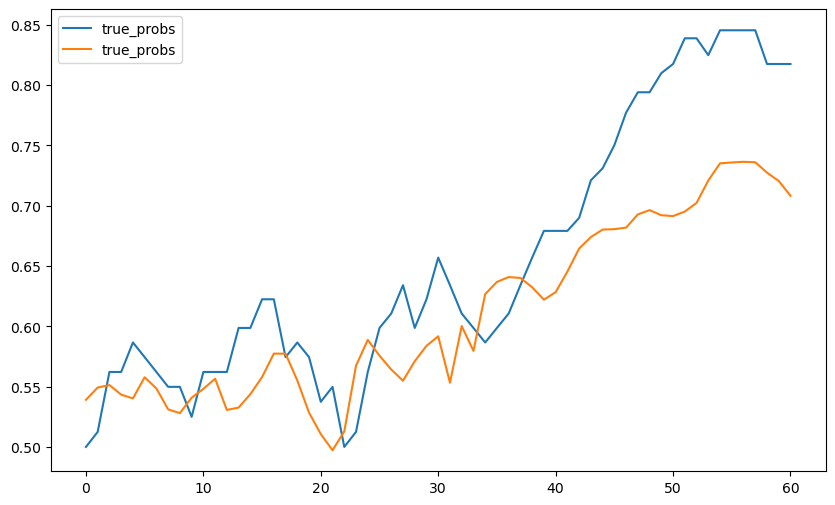

In [99]:
plt.figure(figsize=(10, 6))
plt.plot(test_run_df["steps"],test_run_df["true_probs"], label= "true_probs")
plt.plot(test_run_df["steps"],test_run_df["predictions"], label= "true_probs")
plt.legend()
plt.show()